# 01 — Data Quality & Data Engineering Pipeline

## 1) Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get repo root (one level up from notebooks/)
REPO_ROOT = Path("..").resolve()

# Add repo root to Python path
sys.path.append(str(REPO_ROOT))

REPO_ROOT

PosixPath('/Users/tiagoproenca/Desktop/Business Analytics/T3/Data Ecosystems/dego-project-team15TXC')

## 2) Run the pipeline (raw → curated)

This step:
- reads `data/raw/raw_credit_applications.json`
- exports:
    - `data/curated/credit_applications_curated.csv`
    - `data/artifacts/data_quality_summary.csv`

In [2]:
from src.data_engineer import run
run(REPO_ROOT)

Data engineering pipeline complete.
Raw JSON:     /Users/tiagoproenca/Desktop/Business Analytics/T3/Data Ecosystems/dego-project-team15TXC/data/raw/raw_credit_applications.json
Curated CSV:  /Users/tiagoproenca/Desktop/Business Analytics/T3/Data Ecosystems/dego-project-team15TXC/data/curated/credit_applications_curated.csv
DQ summary:   /Users/tiagoproenca/Desktop/Business Analytics/T3/Data Ecosystems/dego-project-team15TXC/data/artifacts/data_quality_summary.csv


## 3) Load curated outputs

In [3]:
curated_csv = REPO_ROOT / 'data' / 'curated' / 'credit_applications_curated.csv'
dq_path = REPO_ROOT / 'data' / 'artifacts' / 'data_quality_summary.csv'

df = pd.read_csv(curated_csv)
dq = pd.read_csv(dq_path)

df.shape, dq.shape

((500, 32), (32, 5))

In [4]:
df.head(10)

,_id,processing_timestamp,applicant_info.zip_code,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,...,Insurance,Travel,Transportation,Utilities,Groceries,Education,Adult Entertainment,Gambling,total_spend_monthly,loan_approved
0,app_200,2024-01-15T00:00:00Z,10036.0,23,0.20,31212,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1517.0,0
1,app_037,NaN,10032.0,51,0.18,17915,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,947.0,0
2,app_215,NaN,10075.0,41,0.21,37909,NaN,vacation,3.7,59000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,109.0,1
3,app_024,NaN,10077.0,70,0.35,0,NaN,NaN,4.3,34000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,575.0,1
4,app_184,2024-01-15T00:00:00Z,10080.0,14,0.23,31763,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,463.0,0
5,app_275,NaN,10019.0,33,0.05,49933,algorithm_risk_score,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,571.0,0
6,app_099,NaN,10022.0,61,0.17,30159,NaN,NaN,5.6,27000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,458.0,1
7,app_246,NaN,90223.0,31,0.29,21809,NaN,auto,2.8,38000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,478.0,1
8,app_042,NaN,10044.0,43,0.41,15974,algorithm_risk_score,NaN,NaN,NaN,...,153.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,621.0,0
9,app_348,NaN,10080.0,5,0.41,13794,insufficient_credit_history,NaN,NaN,NaN,...,0.0,851.0,0.0,0.0,0.0,0.0,0.0,0.0,1050.0,0


## 4) Data Quality Analysis

### 1 - Completeness

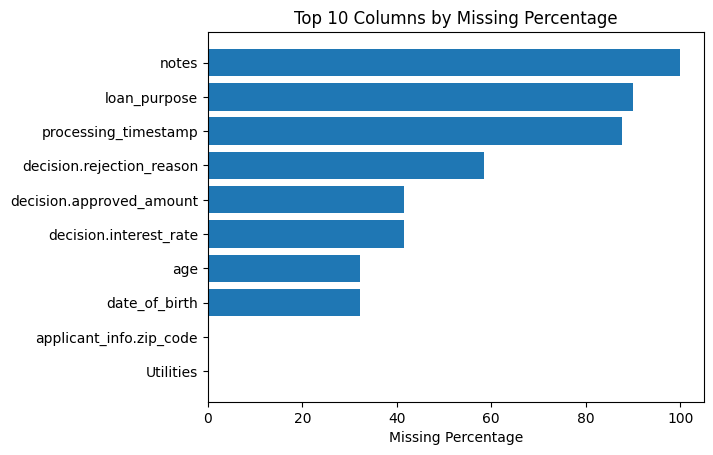

In [5]:
dq_sorted = dq.sort_values("missing_pct", ascending=False)

plt.figure()
plt.barh(dq_sorted["column"][:10], dq_sorted["missing_pct"][:10])
plt.xlabel("Missing Percentage")
plt.title("Top 10 Columns by Missing Percentage")
plt.gca().invert_yaxis()
plt.show()

In [14]:
dq_sorted = dq.sort_values("missing_pct", ascending=False)
dq_sorted.head(10)

,column,dtype,missing_n,missing_pct,n_unique
0,notes,str,500,100.0,0
1,loan_purpose,str,450,90.0,10
2,processing_timestamp,str,438,87.6,4
3,decision.rejection_reason,str,292,58.4,4
4,decision.approved_amount,float64,208,41.6,66
5,decision.interest_rate,float64,208,41.6,41
6,age,Int64,161,32.2,45
7,date_of_birth,datetime64[us],161,32.2,336
25,applicant_info.zip_code,str,0,0.0,196
22,Utilities,float64,0,0.0,74


In [6]:
total = len(df)

missing_summary = {
    "date_of_birth_missing": int(df["date_of_birth"].isna().sum()),
    "age_missing": int(df["age"].isna().sum()),
    "gender_unknown": int((df["gender"] == "Unknown").sum()),
}

missing_summary

{'date_of_birth_missing': 161, 'age_missing': 161, 'gender_unknown': 2}

**Completeness Findings**

- 161 / 500 records (32.2%) have missing `date_of_birth`, therefore `age` is also missing.
- 2 records (0.40%) have unknown gender.
- Spending categories contain NaN where no category was recorded.

**Remediation**

- Date of birth: cannot reliably impute → keep as missing but flag for governance review.
- Gender: standardized unknown values.
- Spending categories: treat missing categories as 0 (no spending).

### 2 - Consistency

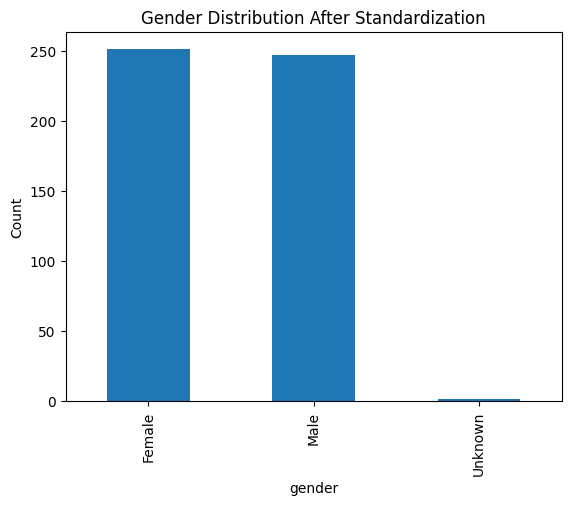

In [7]:
plt.figure()
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution After Standardization")
plt.ylabel("Count")
plt.show()

In [8]:
df['annual_income'].describe()

count       500.000000
mean      82558.865578
std       28102.931999
min           0.000000
25%       63000.000000
50%       81000.000000
75%      101000.000000
max      171000.000000
Name: annual_income, dtype: float64

**Consistency Findings**

- Income fields were inconsistent (`annual_income` vs `annual_salary`).
- Unified into a single numeric `annual_income` column.
- Gender values (M, F, empty) standardized to {Male, Female, Unknown}.

### 3 - Validity

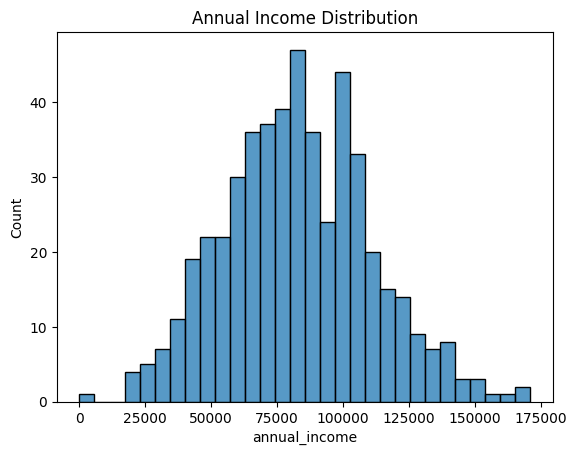

In [9]:
plt.figure()
sns.histplot(df["annual_income"], bins=30)
plt.title("Annual Income Distribution")
plt.show()

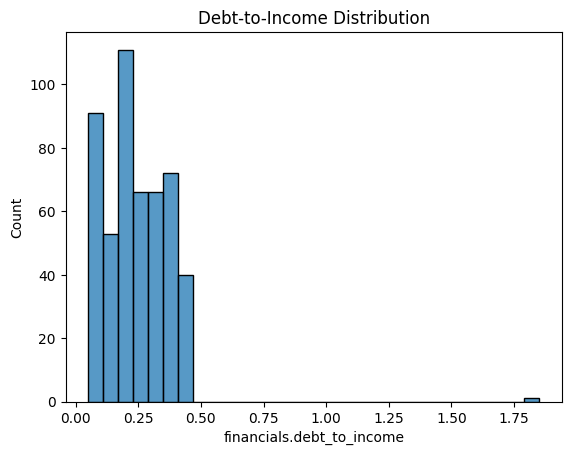

In [10]:
if "financials.debt_to_income" in df.columns:
    plt.figure()
    sns.histplot(pd.to_numeric(df["financials.debt_to_income"], errors="coerce"), bins=30)
    plt.title("Debt-to-Income Distribution")
    plt.show()

In [11]:
validity = {}

income = pd.to_numeric(df["annual_income"], errors="coerce")
validity["annual_income_nonpositive"] = int((income <= 0).sum())

if "financials.debt_to_income" in df.columns:
    dti = pd.to_numeric(df["financials.debt_to_income"], errors="coerce")
    validity["dti_outside_0_1"] = int(((dti < 0) | (dti > 1)).sum())

validity

{'annual_income_nonpositive': 1, 'dti_outside_0_1': 1}

**Validity Findings**

- 1 record with non-positive income.
- 1 record with debt-to-income outside [0,1].
- No ages outside reasonable bounds (18–100).

**Remediation**

- Non-positive income → flag for review.
- DTI outside range → flag for review.
- No extreme age anomalies detected.

### 4 - Uniqueness

In [12]:
dup_ids = df["_id"].duplicated().sum()
dup_ids

np.int64(0)

**Uniqueness Findings**

- `_id` is expected to be unique.
- Records flagged in `notes` as `DUPLICATE_ENTRY_ERROR` or `RESUBMISSION` were removed during curation.
- After remediation, duplicate `_id` count in curated data: **0** .

### 5 - Accuracy

In [13]:
inconsistent = df[
    (df["loan_approved"] == 1) &
    (df["decision.approved_amount"].isna())
]

len(inconsistent)

0

In [16]:
reject_with_amount = df[
    (df["loan_approved"] == 0) &
    (df["decision.approved_amount"].notna())
]
len(reject_with_amount)

0

**Accuracy Checks**

- Checked logical consistency between loan approval and approved amount.
- Approved loans with missing `approved_amount`: 0 records.
- Rejected loans with non-null `approved_amount`: 0 records.

## Final Data Quality Assessment Summary

After data engineering and remediation steps, the curated dataset contains **500 records and 32 columns**.

Key findings:

- **Completeness:** 32% of records lack `date_of_birth`, resulting in missing `age`. This is a structural limitation that may affect downstream modeling and fairness analysis.
- **Consistency:** Schema inconsistencies (e.g., income field naming, gender encodings) were successfully standardized.
- **Validity:** Minor anomalies were detected (1 non-positive income, 1 out-of-range debt-to-income value). These were flagged for governance review.
- **Uniqueness:** Records explicitly marked as `DUPLICATE_ENTRY_ERROR` or `RESUBMISSION` were removed, reducing the dataset from 502 to 500 records and eliminating duplicate bias.
- **Accuracy:** Logical consistency between approval status and approved amount was verified.

The resulting curated dataset is structurally consistent, privacy-aware (direct identifiers removed), and suitable for bias detection and governance evaluation in subsequent project phases.